# Early Universe Cosmology - HW1 P3: $g_*$ calculation
### Marius Kongsore, 2021

In [1]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy.integrate as integrate

First, I set up some plotting defaults.

In [2]:
# Line styles
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.antialiased'] = True
mpl.rcParams['lines.dashed_pattern'] = 2.8, 1.5
mpl.rcParams['lines.dashdot_pattern'] = 4.8, 1.5, 0.8, 1.5
mpl.rcParams['lines.dotted_pattern'] = 1.1, 1.1
mpl.rcParams['lines.scale_dashes']  = True
# Default colors
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler('color',['cornflowerblue','forestgreen','maroon','goldenrod','firebrick','mediumorchid'])
# Fonts
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'CMU Serif'
mpl.rcParams['font.sans-serif'] = 'CMU Sans Serif, DejaVu Sans, Bitstream Vera Sans, Lucida Grande, Verdana, Geneva, Lucid, Arial, Helvetica, Avant Garde, sans-serif'
# Axes
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['axes.labelsize'] = 25
mpl.rcParams['axes.labelpad'] = 9.0
                                                  
                                                  
# Tick marks - the essence of life
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['xtick.minor.width'] = 0.75
mpl.rcParams['xtick.major.pad'] = 8
mpl.rcParams['xtick.labelsize'] = 22
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 2.5
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['ytick.minor.width'] = 0.75
mpl.rcParams['ytick.major.pad'] = 8
mpl.rcParams['ytick.labelsize'] = 22
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['ytick.minor.visible'] = True
# Legend
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.framealpha'] = 0.8
#mpl.rcParams['legend.edgecolor'] = 'black'
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.borderpad'] = 0.4 # border whitespace
mpl.rcParams['legend.labelspacing'] = 0.5 # the vertical space between the legend entries
mpl.rcParams['legend.handlelength'] = 1.5 # the length of the legend lines
mpl.rcParams['legend.handleheight'] = 0.7 # the height of the legend handle
mpl.rcParams['legend.handletextpad'] = 0.5 # the space between the legend line and legend text
mpl.rcParams['legend.borderaxespad'] = 0.5 # the border between the axes and legend edge
mpl.rcParams['legend.columnspacing'] = 2.0 # column separation
# Figure size
mpl.rcParams['figure.figsize'] = 10, 6
# Save details
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.1
mpl.rcParams['xtick.labelsize'] = 22
mpl.rcParams['ytick.labelsize'] = 22

We can obtain the $g_*(T_\gamma)$ function from Kolb and Turner (3.61)

\begin{equation}
g_* = \frac{30}{\pi^2}\frac{\rho_R}{T_\gamma^4}
\end{equation}

where by Kolb and Turner (3.59), the energy density of all species $\rho_R$ is given by 

\begin{equation}
    \rho_R = T_\gamma^4 \sum_{i} \bigg( \frac{T_i}{T_\gamma} \bigg)^4 \frac{g_i}{2\pi^2} \int_{x_i}^\infty \frac{(u^2-x_i^2)^{1/2}u^2 du}{\exp(u-y_i)\pm 1}
\end{equation}

where +1 is for fermions and -1 is for bosons, $x_i=\frac{m_i}{T_\gamma}$, and $y_i=\frac{\mu_i}{T_\gamma}$. We were given $g_i$ for different elementary particles in class, and I found $g_i$ for $\pi^\pm$ and $\pi^0$ in the appendix of https://arxiv.org/pdf/1609.04979.pdf. Let's list them here.

| Species | $\pmb{g_i}$
| --- | --- |
| Neutrino | $2$
| Charged Lepton | $4$
| Quark | $4\times 3$
| Photon | $2$
| Gluon | $2\times 8$
| Massive Vector Boson | $3$
| Higgs Boson | $1$
| $\pi^\pm$ | $2$
| $\pi^0$ | $1$


Next, I initialize these values

In [3]:
g_v = 2
g_charged_lepton = 4
g_quark = 12
g_photon = 2
g_gluon = 16
g_massive_vector_boson = 3
g_h = 1
g_pion_plus_minus = 1
g_pion_zero = 1

Combining the above two equations, and explicitly writing out the $T_\gamma$ dependence and assuming $\mu_i\approx 0$, we get

\begin{equation}
g_*(T_\gamma) = \frac{30}{\pi^2}\sum_{i} \bigg( \frac{T_i}{T_\gamma} \bigg)^4 \frac{g_i}{2\pi^2} \int_{\frac{m_i}{T_\gamma}}^\infty \frac{(u^2-(\frac{m_i}{T_\gamma})^2)^{1/2}u^2 du}{\exp(u)\pm 1}
\end{equation}

We will evaluate the integral numerically using $\text{scipy.integrate.quad}$. One can also simplify this expression by assuming particles "turn off" once $T_\gamma<m_i$. This is described by Kolb and Turner (3.62)

\begin{equation}
    g_{*,simple}(T_\gamma) = \sum_{i=bosons} g_i \bigg( \frac{T_i}{T_\gamma} \bigg)^4+\frac{7}{8}\sum_{i=fermions} g_i \bigg( \frac{T_i}{T_\gamma} \bigg)^4 \:\:\:\:\: \text{for}\: m_i> T
\end{equation}

I will plot the numerically integrated $g_*$ alongside $g_{*,simple}$ for comparison.

For $T_\gamma>150 \, \text{MeV}$, we will consider $\rho_R$ to be dominated by quarks and gluons. For $T_\gamma<150 \, \text{MeV}$, we include $\pi^\pm$ and $\pi^0$ and neglect other hadrons. For neutrinos, we assume $T_\nu=T_\gamma$ when $T_\gamma> m_e$ and $T_\nu = (4/11)^{1/3}T_\gamma$ when $T_\gamma < m_e$. For all other particles, I assume thermal equilibrium with photons by setting $T_i=T_\gamma$.

Below I initialize the standard model (and pion) particle masses. I found these masses on https://pdglive.lbl.gov/. Note that I set the neutrino mass to zero, since it is small enought to be negligible.

In [4]:
# Lepton Masses
m_e = 0.511 # [MeV]
m_mu = 105.66 # [MeV]
m_tau = 1776.86 # [MeV]

# Neutrino Masses
m_v_e = 0.
m_v_mu = 0.
m_v_tau = 0.

# Quark Masses
m_u_quark = 2.16 # [MeV]
m_d_quark = 4.67 # [MeV]
m_s_quark = 93 # [MeV]
m_c_quark = 1.27e3 # [MeV]
m_b_quark = 4.18e3 # [MeV]
m_t_quark = 172.76e3 # [MeV]

# Guage Boson Masses
m_photon = 0.
m_gluon = 0.
m_w = 80.379e3 # [MeV]
m_z = 91.1876e3 # [MeV]

# Scalar Boson Masses
m_h = 125.25e3 # [MeV]

# Hadron Masses
m_pi_plus = 139.570 # [MeV]
m_pi_zero = 134.977 # [MeV]

Next, I initialize my $T_\gamma$ array and $G_*$ arrays.

In [5]:
T_array = np.logspace(-2,7,1000) # Temp scale [MeV]
g_star_array = np.zeros(np.shape(T_array))
g_star_array_simple = np.zeros(np.shape(T_array))

Next, I define the integrand of $g_*$ and subsequently $g_*$ and $g_{*,simple}$ as python functions, making sure to satisfy the particle-by-particle conditions outlined above.

In [6]:
def rho_integrand(u,m_i,T,stats):
    if stats == 'fermi':
        integral = (u**2-(m_i/T)**2)**(1/2)*u**2/(np.exp(u)+1)
    elif stats == 'bose':
        integral = (u**2-(m_i/T)**2)**(1/2)*u**2/(np.exp(u)-1)
    else:
        raise ValueError("Invalid statistics label: "+str(stats)+". Set to 'fermi' or 'bose'.")
    return integral

def g_star(T,m_i,g_i,stats,type):
    
    if type == 'neutrino' and T < m_e:
        
        g_star = 30/np.pi**2*((4/11)**(1/3)*T/T)**4*g_i/(2*np.pi**2)*integrate.quad(lambda x: rho_integrand(x,m_i,T,stats),m_i/T,np.inf)[0]    
    
    elif type == 'pion' and T>150:
        
        g_star = 0.
        
    elif type == 'quark' and T<150:
        
        g_star = 0.
    
    elif type == 'gluon' and T<150:
        
        g_star = 0.
        
    else:
        
        g_star = 30/(np.pi**2)*(T/T)**4*g_i/(2*np.pi**2)*integrate.quad(lambda x: rho_integrand(x,m_i,T,stats),m_i/T,np.inf)[0]

    return g_star

def g_star_simple(T,m_i,g_i,stats,type):
    
    if type == 'neutrino' and T < m_e:
        
        g_star = 7/8*((4/11)**(1/3)*T/T)**4*g_i
    
    elif type == 'pion' and T>150:
        
        g_star = 0.
        
    elif type == 'quark' and T<150:
        
        g_star = 0.
    
    elif type == 'gluon' and T<150:
        
        g_star = 0.
        
    else:
        
        if stats == 'fermi' and T>m_i:
            g_star = 7/8*(T/T)**4*g_i
        elif stats == 'bose' and T>m_i:
            g_star = (T/T)**4*g_i
        else:
            g_star = 0.

    return g_star

Next, I create an array of dictionaries, with each dictionary containing $g_i$, $m_i$, a statistics label, and a type label for a single particle species.

In [7]:
e = {'m':m_e,
     'g':g_charged_lepton,
     'stats': 'fermi',
     'type': 'charged lepton'}

mu = {'m':m_mu,
      'g':g_charged_lepton,
      'stats': 'fermi',
      'type': 'charged lepton'}

tau = {'m':m_tau,
       'g':g_charged_lepton,
       'stats': 'fermi',
       'type': 'charged lepton'}

v_e = {'m': 0.,
       'g': g_v,
       'stats': 'fermi',
       'type': 'neutrino'}

v_mu = {'m': 0.,
        'g': g_v,
        'stats': 'fermi',
        'type': 'neutrino'}

v_tau = {'m': 0.,
         'g': g_v,
         'stats': 'fermi',
         'type': 'neutrino'}

u_quark = {'m': m_u_quark,
           'g': g_quark,
           'stats': 'fermi',
           'type': 'quark'}

d_quark = {'m': m_d_quark,
           'g': g_quark,
           'stats': 'fermi',
           'type': 'quark'}

s_quark = {'m': m_s_quark,
           'g': g_quark,
           'stats': 'fermi',
           'type': 'quark'}

c_quark = {'m': m_c_quark,
           'g': g_quark,
           'stats': 'fermi',
           'type': 'quark'}

b_quark = {'m': m_b_quark,
           'g': g_quark,
           'stats': 'fermi',
           'type': 'quark'}

t_quark = {'m': m_t_quark,
           'g': g_quark,
           'stats': 'fermi',
           'type': 'quark'}

photon = {'m': 0.,
          'g': g_photon,
          'stats' : 'bose',
          'type' : 'photon'}

gluon = {'m': 0.,
         'g': g_gluon,
         'stats' : 'bose',
         'type' : 'gluon'}

z = {'m': m_z,
     'g': g_massive_vector_boson,
     'stats' : 'bose',
     'type': 'massive boson'}

w = {'m': m_w,
     'g': g_massive_vector_boson,
     'stats' : 'bose',
     'type' : 'massive boson'}

h = {'m': m_h,
     'g': g_h,
     'stats' : 'bose',
     'type': 'scalar boson'}

pi_plus_minus = {'m': m_pi_plus,
                 'g': g_pion_plus_minus,
                 'stats' : 'bose',
                 'type' : 'pion'}

pi_zero = {'m': m_pi_zero,
           'g': g_pion_zero,
           'stats' : 'bose',
           'type' : 'pion'}

particles = np.array([e,mu,tau,v_e,v_mu,
                      v_tau,u_quark,d_quark,
                      s_quark,c_quark,b_quark,
                      t_quark,photon,gluon,
                      z,w,h,pi_plus_minus,
                      pi_zero])

I now compute $g_*$ and $g_{*,simple}$ by integrating/summing up contributions from each particle.

In [8]:
for i,T in enumerate(T_array):
    for p in particles:
        g_star_array[i] += g_star(T,p['m'],p['g'],p['stats'],p['type'])
        g_star_array_simple[i] += g_star_simple(T,p['m'],p['g'],p['stats'],p['type'])

/var/folders/9t/wvdzt26j2xbb2z07kg09jb400000gn/T/ipykernel_3193/398846815.py:3: RuntimeWarning: overflow encountered in exp
  integral = (u**2-(m_i/T)**2)**(1/2)*u**2/(np.exp(u)+1)
/var/folders/9t/wvdzt26j2xbb2z07kg09jb400000gn/T/ipykernel_3193/398846815.py:5: RuntimeWarning: overflow encountered in exp
  integral = (u**2-(m_i/T)**2)**(1/2)*u**2/(np.exp(u)-1)


I then finally plot the result.

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: CMU Serif


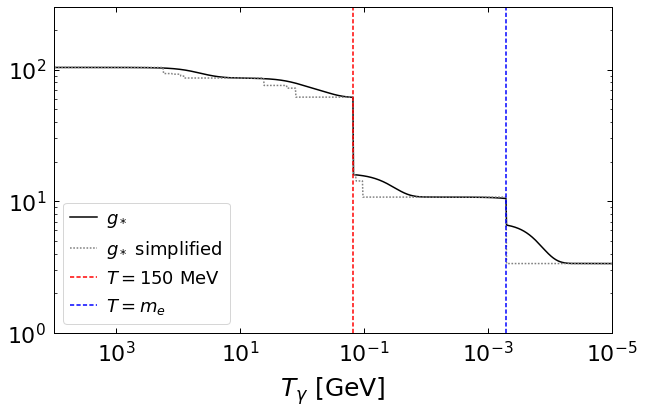

In [9]:
plt.plot(T_array/1000,g_star_array,color='black',label='$g_*$')
plt.plot(T_array/1000,g_star_array_simple,color='gray',label='$g_*$ simplified',linestyle='dotted')
plt.xscale('log')
plt.yscale('log')
plt.gca().invert_xaxis()
plt.xlabel('$T_\gamma$ [GeV]')
plt.ylim(1,300)
plt.xlim(1e4,1e-5)
plt.axvline(0.150,0,1,linestyle='--',color='red',label='$T=150$ MeV')
plt.axvline(m_e/1000,0,1,linestyle='--',color='blue',label='$T=m_e$')
plt.legend()
plt.show()